# Phase 2.4 - Feature Engineering

## Objective

The objective of this notebook is to engineer informative features from the PJM Hourly Energy Consumption dataset to improve forecasting performance.

Feature categories include:

- Calendar Features
- Cyclical Features
- Lag Features
- Rolling Statistics
- Exponential Moving Averages
- Expanding Statistics
- Fourier Features
- Target Variable

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [3]:
DATA_PATH = Path("../data/raw/PJME_hourly.csv")

df = pd.read_csv(DATA_PATH)

df["Datetime"] = pd.to_datetime(df["Datetime"])

df.set_index("Datetime", inplace=True)

# Clean data
df = df.sort_index()
df = df[~df.index.duplicated(keep="first")]

expected_range = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq="h"
)

df = df.reindex(expected_range)
df.index.name = "Datetime"

df["PJME_MW"] = df["PJME_MW"].interpolate(method="time")

print(df.head())

                     PJME_MW
Datetime                    
2002-01-01 01:00:00  30393.0
2002-01-01 02:00:00  29265.0
2002-01-01 03:00:00  28357.0
2002-01-01 04:00:00  27899.0
2002-01-01 05:00:00  28057.0


In [4]:
df["Year"] = df.index.year
df["Quarter"] = df.index.quarter
df["Month"] = df.index.month
df["Week"] = df.index.isocalendar().week.astype(int)
df["Day"] = df.index.day
df["DayOfWeek"] = df.index.dayofweek
df["DayOfYear"] = df.index.dayofyear
df["Hour"] = df.index.hour

df.head()

,PJME_MW,Year,Quarter,Month,Week,Day,DayOfWeek,DayOfYear,Hour
Datetime,,,,,,,,,
2002-01-01 01:00:00,30393.0,2002,1,1,1,1,1,1,1
2002-01-01 02:00:00,29265.0,2002,1,1,1,1,1,1,2
2002-01-01 03:00:00,28357.0,2002,1,1,1,1,1,1,3
2002-01-01 04:00:00,27899.0,2002,1,1,1,1,1,1,4
2002-01-01 05:00:00,28057.0,2002,1,1,1,1,1,1,5


In [5]:
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

df[["DayOfWeek","IsWeekend"]].head()

,DayOfWeek,IsWeekend
Datetime,,
2002-01-01 01:00:00,1,0
2002-01-01 02:00:00,1,0
2002-01-01 03:00:00,1,0
2002-01-01 04:00:00,1,0
2002-01-01 05:00:00,1,0


In [6]:
df["Hour_sin"] = np.sin(2*np.pi*df["Hour"]/24)
df["Hour_cos"] = np.cos(2*np.pi*df["Hour"]/24)

df["Day_sin"] = np.sin(2*np.pi*df["DayOfWeek"]/7)
df["Day_cos"] = np.cos(2*np.pi*df["DayOfWeek"]/7)

df["Month_sin"] = np.sin(2*np.pi*df["Month"]/12)
df["Month_cos"] = np.cos(2*np.pi*df["Month"]/12)

df.head()

,PJME_MW,Year,Quarter,Month,Week,Day,DayOfWeek,DayOfYear,Hour,IsWeekend,Hour_sin,Hour_cos,Day_sin,Day_cos,Month_sin,Month_cos
Datetime,,,,,,,,,,,,,,,,
2002-01-01 01:00:00,30393.0,2002,1,1,1,1,1,1,1,0,0.258819,0.965926,0.781831,0.62349,0.5,0.866025
2002-01-01 02:00:00,29265.0,2002,1,1,1,1,1,1,2,0,0.500000,0.866025,0.781831,0.62349,0.5,0.866025
2002-01-01 03:00:00,28357.0,2002,1,1,1,1,1,1,3,0,0.707107,0.707107,0.781831,0.62349,0.5,0.866025
2002-01-01 04:00:00,27899.0,2002,1,1,1,1,1,1,4,0,0.866025,0.500000,0.781831,0.62349,0.5,0.866025
2002-01-01 05:00:00,28057.0,2002,1,1,1,1,1,1,5,0,0.965926,0.258819,0.781831,0.62349,0.5,0.866025


In [7]:
df["Lag_1"] = df["PJME_MW"].shift(1)
df["Lag_24"] = df["PJME_MW"].shift(24)
df["Lag_48"] = df["PJME_MW"].shift(48)
df["Lag_168"] = df["PJME_MW"].shift(168)

df[["PJME_MW","Lag_1","Lag_24","Lag_168"]].head(30)

,PJME_MW,Lag_1,Lag_24,Lag_168
Datetime,,,,
2002-01-01 01:00:00,30393.0,NaN,NaN,NaN
2002-01-01 02:00:00,29265.0,30393.0,NaN,NaN
2002-01-01 03:00:00,28357.0,29265.0,NaN,NaN
2002-01-01 04:00:00,27899.0,28357.0,NaN,NaN
2002-01-01 05:00:00,28057.0,27899.0,NaN,NaN
2002-01-01 06:00:00,28654.0,28057.0,NaN,NaN
2002-01-01 07:00:00,29308.0,28654.0,NaN,NaN
2002-01-01 08:00:00,29595.0,29308.0,NaN,NaN
2002-01-01 09:00:00,29943.0,29595.0,NaN,NaN


In [8]:
df["RollingMean_24"] = df["PJME_MW"].rolling(24).mean()
df["RollingStd_24"] = df["PJME_MW"].rolling(24).std()

df["RollingMean_168"] = df["PJME_MW"].rolling(168).mean()
df["RollingStd_168"] = df["PJME_MW"].rolling(168).std()

df.head(30)

,PJME_MW,Year,Quarter,Month,Week,Day,DayOfWeek,DayOfYear,Hour,IsWeekend,Hour_sin,Hour_cos,Day_sin,Day_cos,Month_sin,Month_cos,Lag_1,Lag_24,Lag_48,Lag_168,RollingMean_24,RollingStd_24,RollingMean_168,RollingStd_168
Datetime,,,,,,,,,,,,,,,,,,,,,,,,
2002-01-01 01:00:00,30393.0,2002,1,1,1,1,1,1,1,0,2.588190e-01,9.659258e-01,0.781831,0.623490,0.5,0.866025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-01-01 02:00:00,29265.0,2002,1,1,1,1,1,1,2,0,5.000000e-01,8.660254e-01,0.781831,0.623490,0.5,0.866025,30393.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-01-01 03:00:00,28357.0,2002,1,1,1,1,1,1,3,0,7.071068e-01,7.071068e-01,0.781831,0.623490,0.5,0.866025,29265.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-01-01 04:00:00,27899.0,2002,1,1,1,1,1,1,4,0,8.660254e-01,5.000000e-01,0.781831,0.623490,0.5,0.866025,28357.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-01-01 05:00:00,28057.0,2002,1,1,1,1,1,1,5,0,9.659258e-01,2.588190e-01,0.781831,0.623490,0.5,0.866025,27899.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-01-01 06:00:00,28654.0,2002,1,1,1,1,1,1,6,0,1.000000e+00,6.123234e-17,0.781831,0.623490,0.5,0.866025,28057.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-01-01 07:00:00,29308.0,2002,1,1,1,1,1,1,7,0,9.659258e-01,-2.588190e-01,0.781831,0.623490,0.5,0.866025,28654.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-01-01 08:00:00,29595.0,2002,1,1,1,1,1,1,8,0,8.660254e-01,-5.000000e-01,0.781831,0.623490,0.5,0.866025,29308.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-01-01 09:00:00,29943.0,2002,1,1,1,1,1,1,9,0,7.071068e-01,-7.071068e-01,0.781831,0.623490,0.5,0.866025,29595.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df["EMA_24"] = df["PJME_MW"].ewm(span=24).mean()

df["EMA_168"] = df["PJME_MW"].ewm(span=168).mean()

df.head()

,PJME_MW,Year,Quarter,Month,Week,Day,DayOfWeek,DayOfYear,Hour,IsWeekend,Hour_sin,Hour_cos,Day_sin,Day_cos,Month_sin,Month_cos,Lag_1,Lag_24,Lag_48,Lag_168,RollingMean_24,RollingStd_24,RollingMean_168,RollingStd_168,EMA_24,EMA_168
Datetime,,,,,,,,,,,,,,,,,,,,,,,,,,
2002-01-01 01:00:00,30393.0,2002,1,1,1,1,1,1,1,0,0.258819,0.965926,0.781831,0.62349,0.5,0.866025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30393.000000,30393.000000
2002-01-01 02:00:00,29265.0,2002,1,1,1,1,1,1,2,0,0.500000,0.866025,0.781831,0.62349,0.5,0.866025,30393.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29805.500000,29825.642857
2002-01-01 03:00:00,28357.0,2002,1,1,1,1,1,1,3,0,0.707107,0.707107,0.781831,0.62349,0.5,0.866025,29265.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29281.895315,29330.255796
2002-01-01 04:00:00,27899.0,2002,1,1,1,1,1,1,4,0,0.866025,0.500000,0.781831,0.62349,0.5,0.866025,28357.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28891.807590,28966.027109
2002-01-01 05:00:00,28057.0,2002,1,1,1,1,1,1,5,0,0.965926,0.258819,0.781831,0.62349,0.5,0.866025,27899.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28695.911469,28779.867375


In [10]:
df["ExpandingMean"] = df["PJME_MW"].expanding().mean()

df["ExpandingStd"] = df["PJME_MW"].expanding().std()

df.tail()

,PJME_MW,Year,Quarter,Month,Week,Day,DayOfWeek,DayOfYear,Hour,IsWeekend,Hour_sin,Hour_cos,Day_sin,Day_cos,Month_sin,Month_cos,Lag_1,Lag_24,Lag_48,Lag_168,RollingMean_24,RollingStd_24,RollingMean_168,RollingStd_168,EMA_24,EMA_168,ExpandingMean,ExpandingStd
Datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-08-02 20:00:00,44057.0,2018,3,8,31,2,3,214,20,0,-0.866025,0.500000,0.433884,-0.900969,-0.866025,-0.5,45641.0,46912.0,40289.0,46337.0,39902.916667,6368.579836,35900.238095,6755.525713,41980.487874,37004.280441,32078.721077,6464.225907
2018-08-02 21:00:00,43256.0,2018,3,8,31,2,3,214,21,0,-0.707107,0.707107,0.433884,-0.900969,-0.866025,-0.5,44057.0,45985.0,39938.0,44542.0,39789.208333,6278.997878,35892.583333,6746.397424,42082.528844,37078.265287,32078.797956,6464.270141
2018-08-02 22:00:00,41552.0,2018,3,8,31,2,3,214,22,0,-0.500000,0.866025,0.433884,-0.900969,-0.866025,-0.5,43256.0,44094.0,38610.0,42638.0,39683.291667,6224.428358,35886.119048,6740.413014,42040.086537,37131.208894,32078.863113,6464.295653
2018-08-02 23:00:00,38500.0,2018,3,8,31,2,3,214,23,0,-0.258819,0.965926,0.433884,-0.900969,-0.866025,-0.5,41552.0,40666.0,35950.0,39276.0,39593.041667,6225.262959,35881.500000,6738.341667,41756.879614,37147.407605,32078.907278,6464.295357
2018-08-03 00:00:00,35486.0,2018,3,8,31,3,4,215,0,0,0.000000,1.000000,-0.433884,-0.900969,-0.866025,-0.5,38500.0,37158.0,33072.0,35742.0,39523.375000,6262.939842,35879.976190,6738.402348,41255.209245,37127.745976,32078.930711,6464.279302


In [11]:
daily_period = 24
weekly_period = 24 * 7

df["Daily_Sin"] = np.sin(2*np.pi*np.arange(len(df))/daily_period)
df["Daily_Cos"] = np.cos(2*np.pi*np.arange(len(df))/daily_period)

df["Weekly_Sin"] = np.sin(2*np.pi*np.arange(len(df))/weekly_period)
df["Weekly_Cos"] = np.cos(2*np.pi*np.arange(len(df))/weekly_period)

df.head()

,PJME_MW,Year,Quarter,Month,Week,Day,DayOfWeek,DayOfYear,Hour,IsWeekend,Hour_sin,Hour_cos,Day_sin,Day_cos,Month_sin,Month_cos,Lag_1,Lag_24,Lag_48,Lag_168,RollingMean_24,RollingStd_24,RollingMean_168,RollingStd_168,EMA_24,EMA_168,ExpandingMean,ExpandingStd,Daily_Sin,Daily_Cos,Weekly_Sin,Weekly_Cos
Datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2002-01-01 01:00:00,30393.0,2002,1,1,1,1,1,1,1,0,0.258819,0.965926,0.781831,0.62349,0.5,0.866025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30393.000000,30393.000000,30393.000000,NaN,0.000000,1.000000,0.000000,1.000000
2002-01-01 02:00:00,29265.0,2002,1,1,1,1,1,1,2,0,0.500000,0.866025,0.781831,0.62349,0.5,0.866025,30393.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29805.500000,29825.642857,29829.000000,797.616449,0.258819,0.965926,0.037391,0.999301
2002-01-01 03:00:00,28357.0,2002,1,1,1,1,1,1,3,0,0.707107,0.707107,0.781831,0.62349,0.5,0.866025,29265.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29281.895315,29330.255796,29338.333333,1019.979085,0.500000,0.866025,0.074730,0.997204
2002-01-01 04:00:00,27899.0,2002,1,1,1,1,1,1,4,0,0.866025,0.500000,0.781831,0.62349,0.5,0.866025,28357.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28891.807590,28966.027109,28978.500000,1100.677821,0.707107,0.707107,0.111964,0.993712
2002-01-01 05:00:00,28057.0,2002,1,1,1,1,1,1,5,0,0.965926,0.258819,0.781831,0.62349,0.5,0.866025,27899.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28695.911469,28779.867375,28794.200000,1038.485050,0.866025,0.500000,0.149042,0.988831


In [12]:
df["Target"] = df["PJME_MW"].shift(-1)

df[["PJME_MW","Target"]].tail()

,PJME_MW,Target
Datetime,,
2018-08-02 20:00:00,44057.0,43256.0
2018-08-02 21:00:00,43256.0,41552.0
2018-08-02 22:00:00,41552.0,38500.0
2018-08-02 23:00:00,38500.0,35486.0
2018-08-03 00:00:00,35486.0,NaN


In [13]:
print("="*60)
print("FEATURE ENGINEERING SUMMARY")
print("="*60)

print("Total Features :",len(df.columns))

print("\nFeature Names:\n")

for col in df.columns:
    print(col)

FEATURE ENGINEERING SUMMARY
Total Features : 33

Feature Names:

PJME_MW
Year
Quarter
Month
Week
Day
DayOfWeek
DayOfYear
Hour
IsWeekend
Hour_sin
Hour_cos
Day_sin
Day_cos
Month_sin
Month_cos
Lag_1
Lag_24
Lag_48
Lag_168
RollingMean_24
RollingStd_24
RollingMean_168
RollingStd_168
EMA_24
EMA_168
ExpandingMean
ExpandingStd
Daily_Sin
Daily_Cos
Weekly_Sin
Weekly_Cos
Target


In [14]:
missing = df.isnull().sum()

missing = missing[missing>0]

missing.sort_values(ascending=False)

Lag_168            168
RollingMean_168    167
RollingStd_168     167
Lag_48              48
Lag_24              24
RollingStd_24       23
RollingMean_24      23
Lag_1                1
ExpandingStd         1
Target               1
dtype: int64

In [15]:
df = df.dropna()

print(df.shape)

(145223, 33)


In [16]:
corr = df.corr(numeric_only=True)

target_corr = corr["Target"].sort_values(ascending=False)

target_corr

Target             1.000000
PJME_MW            0.974793
Lag_1              0.907609
Lag_24             0.863593
Lag_168            0.759015
Lag_48             0.747529
EMA_24             0.711157
RollingMean_24     0.696422
EMA_168            0.603681
RollingMean_168    0.564365
RollingStd_24      0.486400
Hour               0.429271
RollingStd_168     0.406930
Weekly_Sin         0.199705
Day_sin            0.195999
ExpandingStd       0.057476
Weekly_Cos         0.048041
ExpandingMean      0.037312
Day                0.000155
Week              -0.043711
DayOfYear         -0.043860
Month             -0.044353
Quarter           -0.045083
Day_cos           -0.048049
Year              -0.058339
Month_cos         -0.090573
Month_sin         -0.117777
DayOfWeek         -0.186505
IsWeekend         -0.226617
Daily_Sin         -0.285432
Hour_cos          -0.373758
Hour_sin          -0.395648
Daily_Cos         -0.463424
Name: Target, dtype: float64

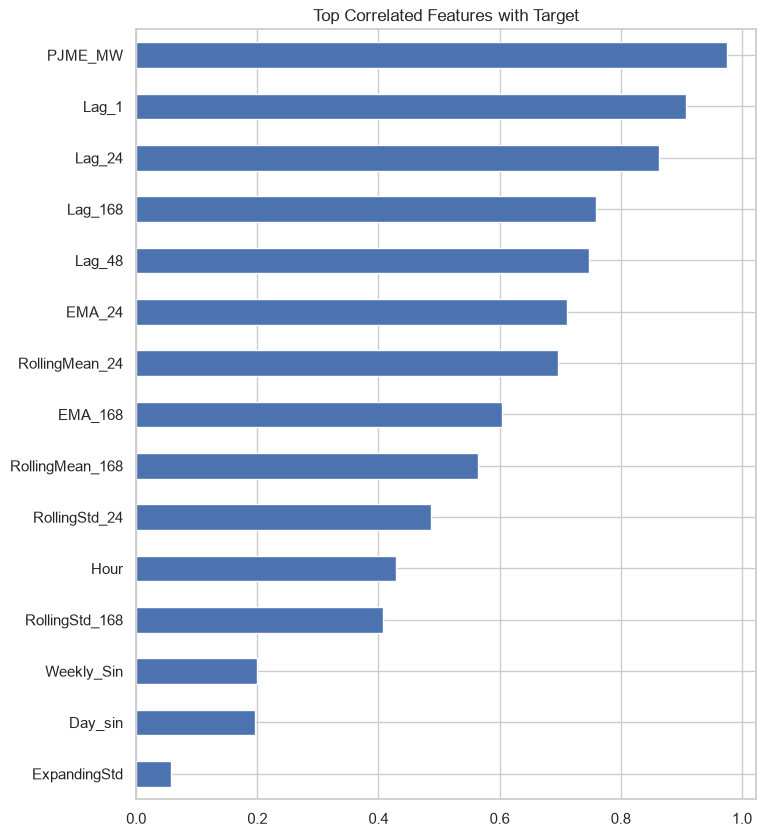

In [17]:
plt.figure(figsize=(8,10))

target_corr.drop("Target").head(15).sort_values().plot(kind="barh")

plt.title("Top Correlated Features with Target")

plt.show()

In [20]:
from pathlib import Path

# Create processed directory if it doesn't exist
output_path = Path("data/processed")
output_path.mkdir(parents=True, exist_ok=True)

# File path
save_path = output_path / "pjm_feature_engineered.csv"

# Save dataset
df.to_csv(save_path, index=True)

print("=" * 60)
print("✅ Feature Engineered Dataset Saved Successfully")
print("=" * 60)
print(f"Saved to: {save_path.resolve()}")

✅ Feature Engineered Dataset Saved Successfully
Saved to: C:\Users\user\mlops-energy-forecasting\notebooks\data\processed\pjm_feature_engineered.csv
